# 04 — Dataset Splits Verification

Verifies the 40 / 10 / 10 / 40 split (train / validation / test / production) that notebook 03 wrote to S3 and to the SageMaker Feature Store offline store.

Required for the Week module deliverable:

> Split your feature data into training (~40%), test (~10%), validation (~10%) datasets. Reserve some data for "production data" (~40%).

In [1]:
import boto3
import pandas as pd
import awswrangler as wr
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from plot_style import apply_style, PURPLE_SENTIMENT, PURPLE_SPLITS

%store -r bucket
%store -r split_prefix
%store -r feature_group_name

apply_style()
report_dir = Path("../reports")
report_dir.mkdir(parents=True, exist_ok=True)

print("Bucket:           ", bucket)
print("Split S3 prefix:  ", split_prefix)
print("Feature group:    ", feature_group_name)

Bucket:            yelp-sentiment-mlops-045456814877
Split S3 prefix:   processed/splits
Feature group:     yelp-sentiment-feature-group-26-01-05-20


## Read each split CSV back from S3

In [2]:
splits = {}
for name in ["train", "validation", "test", "production"]:
    path = f"s3://{bucket}/{split_prefix}/{name}/{name}.csv"
    splits[name] = wr.s3.read_csv(path=path)
    print(f"{name:<10} rows={len(splits[name]):>7,}  positive_share={splits[name]['sentiment_label'].mean():.4f}")

2026-05-26 01:09:29,367	WARNING services.py:2137 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 1909420032 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=4.21gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.


2026-05-26 01:09:29,504	INFO worker.py:2007 -- Started a local Ray instance.


/opt/conda/lib/python3.12/site-packages/ray/_private/worker.py:2046: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


train      rows= 20,000  positive_share=0.5000


validation rows=  5,000  positive_share=0.5000


test       rows=  5,000  positive_share=0.5000


production rows= 20,000  positive_share=0.5000


## Build the summary table

In [3]:
total_rows = sum(len(df) for df in splits.values())
rows = []
for name, df in splits.items():
    rows.append({
        "split_type": name,
        "row_count": len(df),
        "share_of_total": round(len(df) / total_rows, 4),
        "positive_count": int((df["sentiment_label"] == 1).sum()),
        "negative_count": int((df["sentiment_label"] == 0).sum()),
        "positive_share": round(df["sentiment_label"].mean(), 4),
        "avg_review_word_count": round(df["review_word_count"].mean(), 1),
    })
summary_df = pd.DataFrame(rows).set_index("split_type").loc[["train", "validation", "test", "production"]]
summary_df

,row_count,share_of_total,positive_count,negative_count,positive_share,avg_review_word_count
split_type,,,,,,
train,20000,0.4,10000,10000,0.5,109.1
validation,5000,0.1,2500,2500,0.5,109.1
test,5000,0.1,2500,2500,0.5,109.8
production,20000,0.4,10000,10000,0.5,108.6


## Verify each class meets the rubric's 10,000 records per class minimum

The training split is what models learn from, so we apply the floor there.

In [4]:
train_pos = int((splits["train"]["sentiment_label"] == 1).sum())
train_neg = int((splits["train"]["sentiment_label"] == 0).sum())
print(f"Training positive count: {train_pos:,}")
print(f"Training negative count: {train_neg:,}")

rubric_passed = train_pos >= 10000 and train_neg >= 10000
print("Rubric (>=10,000 records per class in train):", "PASS" if rubric_passed else "FAIL")
%store rubric_passed

Training positive count: 10,000
Training negative count: 10,000
Rubric (>=10,000 records per class in train): PASS
Stored 'rubric_passed' (bool)


### Visual proof: split sizes and per-class counts

Two charts saved to `reports/`:

1. `split_row_counts.png` — total rows per split (40/10/10/40 target).
2. `split_class_counts.png` — positive vs negative count per split with a dashed line at **10,000**, the rubric's minimum-records-per-class threshold.

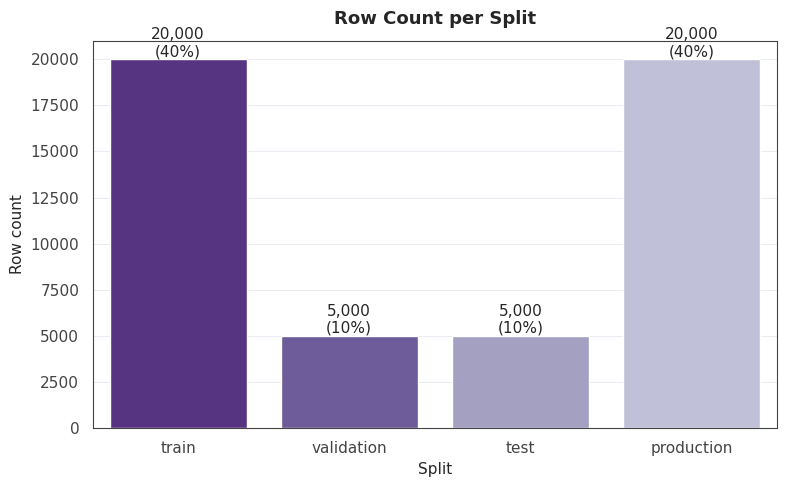

In [5]:
split_order = ["train", "validation", "test", "production"]
plot_summary = summary_df.reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=plot_summary,
    x="split_type",
    y="row_count",
    hue="split_type",
    palette=PURPLE_SPLITS,
    order=split_order,
    legend=False,
    ax=ax,
)
ax.set_title("Row Count per Split")
ax.set_xlabel("Split")
ax.set_ylabel("Row count")
for i, row in plot_summary.iterrows():
    ax.text(i, row["row_count"], f"{int(row['row_count']):,}\n({row['share_of_total']:.0%})",
            ha="center", va="bottom")
plt.tight_layout()
plt.savefig(report_dir / "split_row_counts.png", dpi=150)
plt.show()

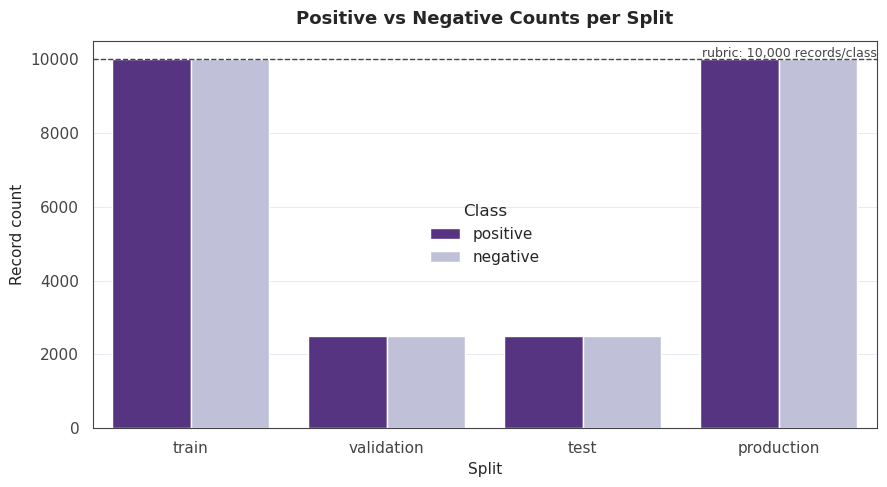

In [6]:
class_df = plot_summary.melt(
    id_vars="split_type",
    value_vars=["positive_count", "negative_count"],
    var_name="class_label",
    value_name="count",
)
class_df["class_label"] = class_df["class_label"].map({"positive_count": "positive", "negative_count": "negative"})

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=class_df,
    x="split_type",
    y="count",
    hue="class_label",
    palette=PURPLE_SENTIMENT,
    order=split_order,
    hue_order=["positive", "negative"],
    ax=ax,
)
ax.axhline(10_000, linestyle="--", color="#444444", linewidth=1)
ax.text(
    len(split_order) - 0.5,
    10_000,
    "rubric: 10,000 records/class",
    ha="right",
    va="bottom",
    color="#444444",
    fontsize=9,
)
ax.set_title("Positive vs Negative Counts per Split")
ax.set_xlabel("Split")
ax.set_ylabel("Record count")
ax.legend(title="Class")
plt.tight_layout()
plt.savefig(report_dir / "split_class_counts.png", dpi=150)
plt.show()

## Persist the summary table to the reports folder

In [7]:
report_dir = Path("../reports")
report_dir.mkdir(parents=True, exist_ok=True)
report_path = report_dir / "dataset_splits_summary.md"

lines = ["# Dataset Splits Summary", "", "Split policy: train 40% | validation 10% | test 10% | production 40%", ""]
lines.append(summary_df.to_markdown())
lines.append("")
lines.append(f"Training records per class meet >=10,000 rubric requirement: **{'PASS' if rubric_passed else 'FAIL'}**")
lines.append(f"")
lines.append(f"Feature Group: `{feature_group_name}`")
lines.append(f"S3 prefix:    `s3://{bucket}/{split_prefix}/`")

report_path.write_text("\n".join(lines), encoding="utf-8")
print("Wrote", report_path)

Wrote ../reports/dataset_splits_summary.md


## Done

The Week module deliverables are complete:

- Raw data is in S3 (`raw/` prefix).
- Athena database `yelp_db` catalogs raw CSV and processed Parquet.
- EDA notebook produced charts and summary in `reports/`.
- Feature engineering ingested labeled records into the SageMaker Feature Store.
- 40 / 10 / 10 / 40 splits are written to S3 and verified above.

Next modules will plug these splits into model training, the SageMaker Pipeline (CI/CD), Model Registry, Batch Transform, and Model Monitor.